# Modeling - AI4BMI (Prédiction de panne à 24h)

Ce notebook construit un pipeline complet d'entraînement basé sur les conclusions EDA :
- cible déséquilibrée (`failure_next_24h`) ;
- signal fort de `maintenance_age_days` ;
- utilité potentielle d'interactions entre capteurs + variables temporelles.

## Plan
1. Imports et configuration
2. Chargement/typage des données
3. Feature engineering + split temporel (train équilibré)
4. Préprocessing
5. Entraînement du modèle retenu (`LogisticRegressionBalanced`)
6. Tuning du seuil de décision
7. Évaluation et interprétabilité
8. Sauvegarde des artefacts

In [14]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import joblib

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [15]:
# Chargement robuste du CSV
candidate_paths = [
    Path('AI4BMI_predictive_maintenance_dataset.csv'),
    Path('../AI4BMI_predictive_maintenance_dataset.csv'),
    Path('../../AI4BMI_predictive_maintenance_dataset.csv')
]

csv_path = None
for p in candidate_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError('CSV introuvable. Placez le fichier dans le repo ou un dossier parent.')

df = pd.read_csv(csv_path)
print('CSV chargé depuis :', csv_path)
print('Shape brute :', df.shape)

CSV chargé depuis : ..\AI4BMI_predictive_maintenance_dataset.csv
Shape brute : (200000, 15)


In [16]:
# Typage explicite aligné sur l'EDA
target_col = 'failure_next_24h'
timestamp_col = 'timestamp'

id_cols = ['machine_id', 'machine_type']
numeric_cols_expected = [
    'maintenance_age_days',
    'vib_mean', 'vib_std', 'vib_rms',
    'temp_mean', 'temp_max',
    'current_mean', 'current_peak',
    'acoustic_energy', 'rpm_mean', 'oil_particle_count'
]

for col in id_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')

if 'machine_type' in df.columns:
    df['machine_type'] = df['machine_type'].astype('category')

if timestamp_col in df.columns:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors='coerce')

for col in numeric_cols_expected:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if target_col in df.columns:
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce').astype('Int64')

print(df.dtypes)
print('NA total :', int(df.isna().sum().sum()))

machine_id              string[python]
machine_type                  category
timestamp               datetime64[ns]
maintenance_age_days             int64
vib_mean                       float64
vib_std                        float64
vib_rms                        float64
temp_mean                      float64
temp_max                       float64
current_mean                   float64
current_peak                   float64
acoustic_energy                float64
rpm_mean                       float64
oil_particle_count             float64
failure_next_24h                 Int64
dtype: object
NA total : 0


In [17]:
# Feature engineering simple (sans fuite)
work_df = df.copy()

if timestamp_col in work_df.columns:
    work_df['hour'] = work_df[timestamp_col].dt.hour
    work_df['day_of_week'] = work_df[timestamp_col].dt.day_name()
    work_df['is_weekend'] = work_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

# Features candidates (basées sur les conclusions EDA)
feature_candidates = [
    'machine_type',
    'maintenance_age_days',
    'vib_mean', 'vib_std', 'vib_rms',
    'temp_mean', 'temp_max',
    'current_mean', 'current_peak',
    'acoustic_energy',
    'rpm_mean',
    'oil_particle_count',
    'hour', 'day_of_week', 'is_weekend'
]

available_features = [c for c in feature_candidates if c in work_df.columns]
required_cols = available_features + [target_col, timestamp_col]

model_df = work_df.dropna(subset=[target_col, timestamp_col]).copy()
model_df = model_df.sort_values(timestamp_col).reset_index(drop=True)

X = model_df[available_features].copy()
y = model_df[target_col].astype(int).copy()

print('Features retenues :', available_features)
print('Shape modeling :', X.shape)
print('Taux classe 1 global :', f'{y.mean():.2%}')

Features retenues : ['machine_type', 'maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms', 'temp_mean', 'temp_max', 'current_mean', 'current_peak', 'acoustic_energy', 'rpm_mean', 'oil_particle_count', 'hour', 'day_of_week', 'is_weekend']
Shape modeling : (200000, 15)
Taux classe 1 global : 17.90%


In [18]:
# Split temporel 80/20 + équilibrage du train (0/1)
split_idx = int(len(model_df) * 0.8)

X_train_full = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()
y_train_full = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

print('Train full:', X_train_full.shape, '| Test:', X_test.shape)
print('Taux classe 1 train full:', f'{y_train_full.mean():.2%}')
print('Taux classe 1 test      :', f'{y_test.mean():.2%}')

# Équilibrage binaire par sous-échantillonnage de la classe majoritaire
idx_0 = y_train_full[y_train_full == 0].index
idx_1 = y_train_full[y_train_full == 1].index
n_min = min(len(idx_0), len(idx_1))

idx_0_sample = idx_0.to_series().sample(n=n_min, random_state=RANDOM_STATE, replace=False).values
idx_1_sample = idx_1.to_series().sample(n=n_min, random_state=RANDOM_STATE, replace=False).values

balanced_idx = np.concatenate([idx_0_sample, idx_1_sample])

X_train = X_train_full.loc[balanced_idx].copy()
y_train = y_train_full.loc[balanced_idx].copy()

# Mélange pour éviter un ordre par classe
df_train_bal = X_train.copy()
df_train_bal[target_col] = y_train.values
df_train_bal = df_train_bal.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)

X_train = df_train_bal.drop(columns=[target_col])
y_train = df_train_bal[target_col].astype(int)

print('Train équilibré:', X_train.shape)
print('Répartition train équilibré:')
print(y_train.value_counts())

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
class_weight_ratio = neg / pos if pos > 0 else np.nan
print('Poids indicatif classe 1 ~', round(class_weight_ratio, 2))

Train full: (160000, 15) | Test: (40000, 15)
Taux classe 1 train full: 17.93%
Taux classe 1 test      : 17.78%
Train équilibré: (57368, 15)
Répartition train équilibré:
failure_next_24h
0    28684
1    28684
Name: count, dtype: int64
Poids indicatif classe 1 ~ 1.0


In [19]:
# Préprocessing
num_features = [c for c in X_train.columns if c not in ['machine_type', 'day_of_week']]
cat_features = [c for c in ['machine_type', 'day_of_week'] if c in X_train.columns]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ],
    remainder='drop'
)

print('Num features:', num_features)
print('Cat features:', cat_features)

Num features: ['maintenance_age_days', 'vib_mean', 'vib_std', 'vib_rms', 'temp_mean', 'temp_max', 'current_mean', 'current_peak', 'acoustic_energy', 'rpm_mean', 'oil_particle_count', 'hour', 'is_weekend']
Cat features: ['machine_type', 'day_of_week']


In [20]:
# Fonctions d'évaluation
def get_scores(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    scores = {
        'threshold': threshold,
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'pr_auc': average_precision_score(y_true, y_prob),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }
    return scores, y_pred

def evaluate_pipeline(name, pipeline, X_train, y_train, X_test, y_test):
    pipeline.fit(X_train, y_train)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    scores, y_pred = get_scores(y_test, y_prob, threshold=0.5)
    return pipeline, y_prob, y_pred, scores

In [35]:
# Entraînement du modèle retenu: Logistic Regression Balanced
log_reg = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        class_weight='balanced',
        max_iter=1200,
        random_state=RANDOM_STATE
    ))
])

model_name = 'LogisticRegressionBalanced'
selected_model, y_scores, y_pred_default, scores_default = evaluate_pipeline(
    model_name, log_reg, X_train, y_train, X_test, y_test
)

results_df = pd.DataFrame([scores_default | {'model': model_name}])
display(results_df[['model', 'recall', 'precision', 'f1', 'pr_auc', 'roc_auc', 'threshold']])

,model,recall,precision,f1,pr_auc,roc_auc,threshold
0,LogisticRegressionBalanced,0.681102,0.278407,0.395251,0.296563,0.701834,0.5


In [ ]:
# Entraînement du modèle retenu
model_outputs = {}
rows = []

fitted, y_prob, y_pred, scores = evaluate_pipeline(model_name, log_reg, X_train, y_train, X_test, y_test)
model_outputs[model_name] = {'model': fitted, 'y_prob': y_prob, 'y_pred': y_pred, 'scores': scores}
rows.append(scores | {'model': model_name})

results_df = pd.DataFrame(rows)
display(results_df[['model', 'recall', 'precision', 'f1', 'pr_auc', 'roc_auc', 'threshold']])

,model,recall,precision,f1,pr_auc,roc_auc,threshold
0,LogisticBalanced,0.681102,0.278407,0.395251,0.296563,0.701834,0.5


In [36]:
# Tuning du seuil de décision (F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

best_thr = 0.5
best_f1 = -1
for thr in np.linspace(0.05, 0.95, 181):
    y_pred_thr = (y_scores >= thr).astype(int)
    f1 = f1_score(y_test, y_pred_thr, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thr = thr

scores_tuned, y_pred_tuned = get_scores(y_test, y_scores, threshold=best_thr)

print('Modèle retenu:', model_name)
print('Seuil défaut 0.50 ->', scores_default)
print(f'Seuil F1 optimal {best_thr:.3f} ->', scores_tuned)

Modèle retenu: LogisticRegressionBalanced
Seuil défaut 0.50 -> {'threshold': 0.5, 'recall': 0.6811023622047244, 'precision': 0.27840680498879244, 'f1': 0.3952511117457468, 'pr_auc': np.float64(0.2965625433390726), 'roc_auc': np.float64(0.7018342017862581)}
Seuil F1 optimal 0.475 -> {'threshold': np.float64(0.4749999999999999), 'recall': 0.7214566929133859, 'precision': 0.2735366243736006, 'f1': 0.3966756861229223, 'pr_auc': np.float64(0.2965625433390726), 'roc_auc': np.float64(0.7018342017862581)}


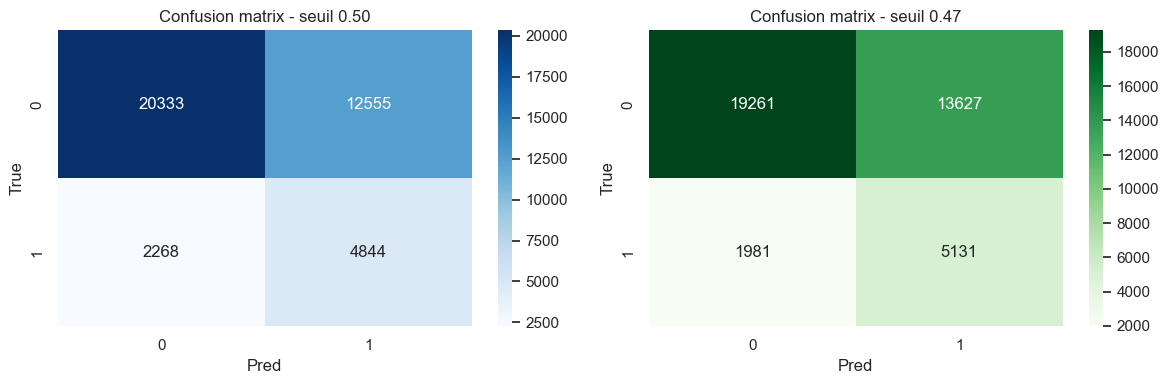

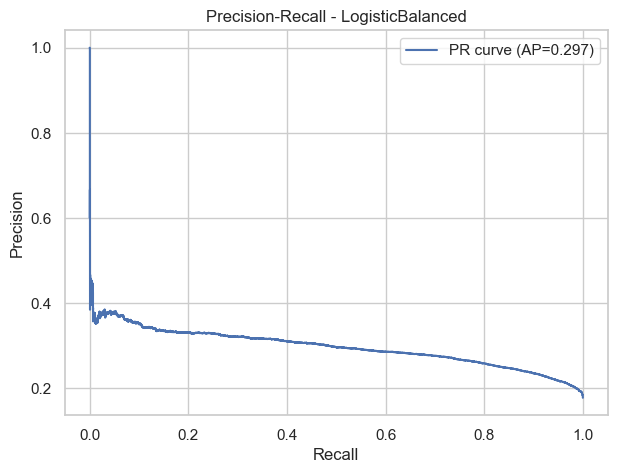

In [ ]:
# Matrices de confusion + courbe Precision-Recall
cm_default = confusion_matrix(y_test, y_pred_default)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix - seuil 0.50')
axes[0].set_xlabel('Pred')
axes[0].set_ylabel('True')

sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion matrix - seuil {best_thr:.2f}')
axes[1].set_xlabel('Pred')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

pr_auc = average_precision_score(y_test, y_scores)
plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'PR curve (AP={pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall - {model_name}')
plt.legend()
plt.show()

In [25]:
# Rapport de classification (seuil tuné)
print(classification_report(y_test, y_pred_tuned, digits=4))

              precision    recall  f1-score   support

           0     0.9067    0.5857    0.7117     32888
           1     0.2735    0.7215    0.3967      7112

    accuracy                         0.6098     40000
   macro avg     0.5901    0.6536    0.5542     40000
weighted avg     0.7942    0.6098    0.6557     40000



,feature,importance
0,num__maintenance_age_days,0.787310
7,num__current_peak,0.034128
19,cat__day_of_week_Saturday,0.033136
4,num__temp_mean,0.031574
20,cat__day_of_week_Sunday,0.030780
6,num__current_mean,0.029820
5,num__temp_max,0.025623
16,cat__machine_type_Robot,0.024260
23,cat__day_of_week_Wednesday,0.021069
1,num__vib_mean,0.017090


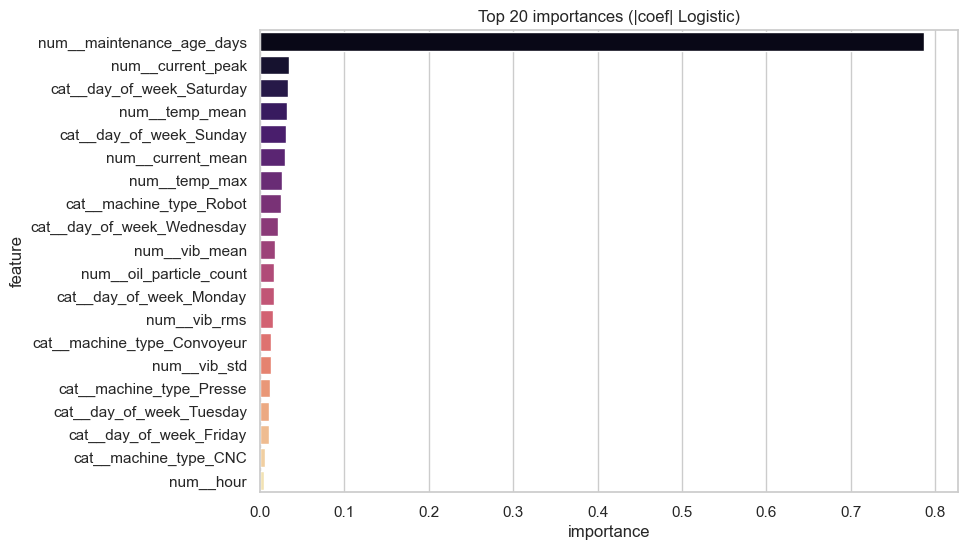

In [33]:
# Interprétabilité: variables importantes du modèle retenu
prep = selected_model.named_steps['prep']
clf = selected_model.named_steps['clf']
feature_names = prep.get_feature_names_out()

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)
    display(imp_df)

    plt.figure(figsize=(9,6))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title('Top 20 importances (RandomForest)')
    plt.show()
elif hasattr(clf, 'coef_'):
    coef = np.abs(clf.coef_[0])
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': coef})
    imp_df = imp_df.sort_values('importance', ascending=False).head(20)
    display(imp_df)

    plt.figure(figsize=(9,6))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='magma')
    plt.title('Top 20 importances (|coef| Logistic)')
    plt.show()
else:
    print('Importances non disponibles pour ce modèle.')

In [ ]:
# Sauvegarde artefacts
artifacts_dir = Path('models')
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'logistic_regression_balanced.pkl'
metadata_path = artifacts_dir / 'logistic_regression_balanced_metadata.json'

joblib.dump(selected_model, model_path)

metadata = {
    'selected_model_name': model_name,
    'features': available_features,
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
    'class_ratio_train': float(y_train.mean()),
    'scores_default_threshold_0_5': {k: float(v) for k, v in scores_default.items()},
    'scores_tuned_threshold': {k: float(v) for k, v in scores_tuned.items()},
    'selected_threshold_f1': float(best_thr)
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print('Artefacts sauvegardés:')
print('-', model_path)
print('-', metadata_path)

Artefacts sauvegardés:
- artifacts\logistic_regression_balanced.pkl
- artifacts\model_metadata.json


## Conclusion modèle

- Ce notebook est simplifié pour n'utiliser que le modèle retenu : `LogisticRegressionBalanced`.
- Le seuil de décision est optimisé sur F1 pour améliorer le compromis rappel/précision en maintenance prédictive.
- Les artefacts exportés (`logistic_regression_balanced.pkl`, `model_metadata.json`) sont prêts pour intégration API et suivi expérimental.

### Prochaines améliorations
1. Validation temporelle glissante (backtesting multi-fenêtres).
2. Calibration de probabilités pour décision métier.
3. Optimisation coût métier (faux positifs vs faux négatifs).